# 05 — Cross-Domain Generalization

## ResNet18: unseen microscope and magnification domains

Notebook 04 achieved **0.9608 Macro-F1** on the standard split but **0.6702** on unseen physical samples. This notebook tests whether the same transfer-learning approach generalizes to completely unseen acquisition domains.

Six independent experiments are run: hold out each of microscopes 0/1/2 and magnifications 20x/50x/100x. Each experiment initializes a fresh ImageNet-pretrained ResNet18; the held-out domain is used only for final testing.

Because the machine is CPU-only, training uses a 5-epoch frozen-head stage followed by up to 20 epochs of `layer4 + head` fine-tuning, with early stopping.


## 1. Configuration


In [1]:
from pathlib import Path

PROCESSED_DIR=Path(r"../data/processed")
MODEL_DIR=Path(r"../models/05_cross_domain")
RESULT_DIR=Path(r"../results/05_cross_domain")

SEED=42
IMAGE_SIZE=160
BATCH_SIZE=32
NUM_WORKERS=0
HEAD_EPOCHS=5
HEAD_LR=1e-3
FINETUNE_EPOCHS=20
FINETUNE_LR=1e-4
PATIENCE=6
MIN_DELTA=1e-4
WEIGHT_DECAY=1e-4

# None = run all six. For a test run use e.g. ["microscope_0"]
RUN_ONLY=None

MODEL_DIR.mkdir(parents=True,exist_ok=True)
RESULT_DIR.mkdir(parents=True,exist_ok=True)
print("Maximum epochs per experiment:",HEAD_EPOCHS+FINETUNE_EPOCHS)


Maximum epochs per experiment: 25


## 2. Imports and device


In [2]:
import copy,random,time,warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
from torchvision.models import resnet18,ResNet18_Weights
from sklearn.metrics import accuracy_score,balanced_accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,roc_curve
from IPython.display import display
warnings.filterwarnings("ignore")

def set_seed(s=42):
    random.seed(s);np.random.seed(s);torch.manual_seed(s)
    if torch.cuda.is_available():torch.cuda.manual_seed_all(s)
set_seed(SEED)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:",torch.__version__)
print("Device:",device)


PyTorch: 2.14.0+cpu
Device: cpu


## 3. Discover and audit Notebook 02 holdout manifests


In [3]:
mic_files=sorted(PROCESSED_DIR.glob("split_holdout_microscope_*.csv"))
mag_files=sorted(PROCESSED_DIR.glob("split_holdout_magnification_*.csv"))
assert mic_files and mag_files,"Holdout manifests missing. Run Notebook 02 first."

experiments={}
for p in mic_files:
    held=p.stem.replace("split_holdout_microscope_","")
    experiments[f"microscope_{held}"]={"family":"Microscope","heldout":held,"df":pd.read_csv(p)}
for p in mag_files:
    held=p.stem.replace("split_holdout_magnification_","")
    experiments[f"magnification_{held}"]={"family":"Magnification","heldout":held,"df":pd.read_csv(p)}
if RUN_ONLY is not None:experiments={k:v for k,v in experiments.items() if k in RUN_ONLY}
assert experiments,"No experiments selected."

audit=[]
for key,e in experiments.items():
    df=e["df"]
    assert {"image_path","Phase","label","split"}.issubset(df.columns)
    for s in ["train","val","test"]:
        d=df[df.split==s]
        assert len(d)>0 and d.Phase.nunique()==2,f"{key}/{s} lacks both classes"
        audit.append([key,e["family"],e["heldout"],s,len(d),(d.Phase=="Bainite").sum(),(d.Phase=="Martensite").sum()])
audit=pd.DataFrame(audit,columns=["experiment","family","heldout","split","n","bainite","martensite"])
display(audit)


,experiment,family,heldout,split,n,bainite,martensite
0,microscope_0,Microscope,0,train,2497,1138,1359
1,microscope_0,Microscope,0,val,549,285,264
2,microscope_0,Microscope,0,test,2247,1047,1200
3,microscope_1,Microscope,1,train,3646,1657,1989
4,microscope_1,Microscope,1,val,804,420,384
5,microscope_1,Microscope,1,test,843,393,450
6,microscope_2,Microscope,2,train,2529,1143,1386
7,microscope_2,Microscope,2,val,561,297,264
8,microscope_2,Microscope,2,test,2203,1030,1173
9,magnification_100x,Magnification,100x,train,4128,1869,2259


## 4. Verify held-out-domain isolation


In [4]:
for key,e in experiments.items():
    df=e["df"];tv=df[df.split.isin(["train","val"])];te=df[df.split=="test"]
    col="MicroscopeID" if e["family"]=="Microscope" else "Magnification"
    held=str(e["heldout"])
    assert held not in set(tv[col].astype(str)),f"Leakage in {key}"
    assert set(te[col].astype(str))=={held},f"Unexpected test domain in {key}"
    assert all(Path(p).exists() for p in pd.concat([tv,te]).image_path)
    print("✓",key,"isolated correctly")


✓ microscope_0 isolated correctly
✓ microscope_1 isolated correctly
✓ microscope_2 isolated correctly
✓ magnification_100x isolated correctly
✓ magnification_20x isolated correctly
✓ magnification_50x isolated correctly


# Part A — Preprocessing and data loaders

We retain Notebook 04's 160×160 input size, ImageNet normalization, flips and ±10° rotations for controlled comparison.


In [5]:
weights=ResNet18_Weights.DEFAULT
MEAN=[.485,.456,.406];STD=[.229,.224,.225]
train_transform=transforms.Compose([transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),transforms.RandomHorizontalFlip(.5),transforms.RandomVerticalFlip(.5),transforms.RandomRotation(10),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
eval_transform=transforms.Compose([transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])

class MicroDataset(Dataset):
    def __init__(self,df,transform):self.df=df.reset_index(drop=True).copy();self.transform=transform
    def __len__(self):return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        with Image.open(r.image_path) as im:x=im.convert("RGB")
        return self.transform(x),torch.tensor(int(r.label),dtype=torch.long),i

def loaders(df):
    parts={s:df[df.split==s].copy() for s in ["train","val","test"]}
    ds={s:MicroDataset(parts[s],train_transform if s=="train" else eval_transform) for s in parts}
    common=dict(batch_size=BATCH_SIZE,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
    g=torch.Generator().manual_seed(SEED)
    ld={"train":DataLoader(ds["train"],shuffle=True,generator=g,**common),"val":DataLoader(ds["val"],shuffle=False,**common),"test":DataLoader(ds["test"],shuffle=False,**common)}
    return parts,ds,ld


# Part B — Model, metrics and training


In [6]:
def build_model():
    m=resnet18(weights=weights);n=m.fc.in_features;m.fc=nn.Sequential(nn.Dropout(.35),nn.Linear(n,2));return m
def freeze(m):
    for p in m.parameters():p.requires_grad=False
    for p in m.fc.parameters():p.requires_grad=True
def unfreeze4(m):
    for p in m.parameters():p.requires_grad=False
    for p in m.layer4.parameters():p.requires_grad=True
    for p in m.fc.parameters():p.requires_grad=True
def mets(y,p,prob):
    return {"accuracy":accuracy_score(y,p),"balanced_accuracy":balanced_accuracy_score(y,p),"precision_macro":precision_score(y,p,average="macro",zero_division=0),"recall_macro":recall_score(y,p,average="macro",zero_division=0),"f1_macro":f1_score(y,p,average="macro",zero_division=0),"roc_auc":roc_auc_score(y,prob)}

@torch.inference_mode()
def evaluate(m,ld,criterion):
    m.eval();loss=0;y=[];p=[];prob=[];idx=[]
    for x,t,i in ld:
        x=x.to(device);t=t.to(device);z=m(x);l=criterion(z,t);q=torch.softmax(z,1)[:,1];pr=z.argmax(1)
        loss+=l.item()*len(x);y.extend(t.cpu().numpy());p.extend(pr.cpu().numpy());prob.extend(q.cpu().numpy());idx.extend(i.numpy())
    out=mets(y,p,prob);out["loss"]=loss/len(ld.dataset)
    return out,np.array(y),np.array(p),np.array(prob),np.array(idx)


In [7]:
def stage(m,ds,ld,name,epochs,lr,best=-np.inf,state=None,offset=0):
    criterion=nn.CrossEntropyLoss();opt=torch.optim.AdamW([p for p in m.parameters() if p.requires_grad],lr=lr,weight_decay=WEIGHT_DECAY)
    sched=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,mode="max",factor=.5,patience=3,min_lr=1e-7)
    hist=[];stale=0
    for e in range(1,epochs+1):
        m.train();loss=0;y=[];p=[];prob=[]
        for x,t,_ in ld["train"]:
            x=x.to(device);t=t.to(device);opt.zero_grad(set_to_none=True);z=m(x);l=criterion(z,t);l.backward();opt.step()
            q=torch.softmax(z,1)[:,1];pr=z.argmax(1);loss+=l.item()*len(x);y.extend(t.detach().cpu().numpy());p.extend(pr.detach().cpu().numpy());prob.extend(q.detach().cpu().numpy())
        tm=mets(y,p,prob);tm["loss"]=loss/len(ds["train"]);vm,*_=evaluate(m,ld["val"],criterion);sched.step(vm["f1_macro"])
        ep=offset+e;hist.append({"epoch":ep,"stage":name,**{f"train_{k}":v for k,v in tm.items()},**{f"val_{k}":v for k,v in vm.items()}})
        print(f"Epoch {ep:02d} | {name:9s} | train F1 {tm['f1_macro']:.4f} | val F1 {vm['f1_macro']:.4f} | val AUC {vm['roc_auc']:.4f}")
        if vm["f1_macro"]>best+MIN_DELTA:best=vm["f1_macro"];state=copy.deepcopy(m.state_dict());stale=0
        else:stale+=1
        if stale>=PATIENCE:print("Early stopping",name);break
    return m,pd.DataFrame(hist),best,state


## 5. Complete one domain-holdout experiment

A fresh pretrained model is created for every domain, preventing cross-experiment weight leakage. Checkpoints and prediction CSVs are saved immediately after each completed run.


In [8]:
def run_experiment(key,e):
    print("\n"+"="*84+f"\n{key}\n"+"="*84);set_seed(SEED);parts,ds,ld=loaders(e["df"]);m=build_model().to(device);start=time.time()
    freeze(m);m,h1,best,state=stage(m,ds,ld,"head",HEAD_EPOCHS,HEAD_LR)
    m.load_state_dict(state);unfreeze4(m);m,h2,best,state=stage(m,ds,ld,"fine_tune",FINETUNE_EPOCHS,FINETUNE_LR,best,state,len(h1));m.load_state_dict(state)
    hist=pd.concat([h1,h2],ignore_index=True);criterion=nn.CrossEntropyLoss();tm,y,p,prob,idx=evaluate(m,ld["test"],criterion);minutes=(time.time()-start)/60
    ck=MODEL_DIR/f"{key}_best.pt";torch.save({"model_state_dict":state,"heldout":e["heldout"],"family":e["family"],"image_size":IMAGE_SIZE,"best_val_f1":float(best)},ck);hist.to_csv(RESULT_DIR/f"{key}_history.csv",index=False)
    pred=parts["test"].reset_index(drop=True).iloc[idx].reset_index(drop=True).copy();pred["true_label"]=y;pred["predicted_label"]=p;pred["p_martensite"]=prob;pred.to_csv(RESULT_DIR/f"{key}_test_predictions.csv",index=False)
    print("TEST:", {k:round(v,4) for k,v in tm.items()},f" | {minutes:.1f} min")
    return {"key":key,"family":e["family"],"heldout":e["heldout"],"metrics":tm,"y":y,"p":p,"prob":prob,"history":hist,"parts":parts,"minutes":minutes,"checkpoint":ck}


# Part C — Run the six experiments

**This is the long-running cell.** On CPU, expect this notebook to take substantially longer than Notebook 04 because six independent models are trained. Each completed experiment is saved before the next begins.


In [9]:
results={}
for key,e in experiments.items():
    results[key]=run_experiment(key,e)
print("\n✓ All requested domain experiments completed.")



microscope_0
Epoch 01 | head      | train F1 0.6351 | val F1 0.5756 | val AUC 0.6345
Epoch 02 | head      | train F1 0.7123 | val F1 0.6500 | val AUC 0.7109
Epoch 03 | head      | train F1 0.7286 | val F1 0.6693 | val AUC 0.7330
Epoch 04 | head      | train F1 0.7347 | val F1 0.6623 | val AUC 0.7380
Epoch 05 | head      | train F1 0.7517 | val F1 0.6885 | val AUC 0.7494
Epoch 06 | fine_tune | train F1 0.8104 | val F1 0.6973 | val AUC 0.7868
Epoch 07 | fine_tune | train F1 0.8651 | val F1 0.7163 | val AUC 0.7877
Epoch 08 | fine_tune | train F1 0.8938 | val F1 0.6649 | val AUC 0.7885
Epoch 09 | fine_tune | train F1 0.9208 | val F1 0.6837 | val AUC 0.7988
Epoch 10 | fine_tune | train F1 0.9293 | val F1 0.7066 | val AUC 0.7902
Epoch 11 | fine_tune | train F1 0.9298 | val F1 0.6568 | val AUC 0.7455
Epoch 12 | fine_tune | train F1 0.9482 | val F1 0.7260 | val AUC 0.8009
Epoch 13 | fine_tune | train F1 0.9616 | val F1 0.6867 | val AUC 0.7702
Epoch 14 | fine_tune | train F1 0.9649 | val F1 0.

# Part D — Aggregate results


In [10]:
rows=[]
for key,r in results.items():
    m=r["metrics"];rows.append({"Experiment":key,"Domain family":r["family"],"Held-out domain":r["heldout"],"Test images":len(r["y"]),"Accuracy":m["accuracy"],"Balanced Accuracy":m["balanced_accuracy"],"Macro F1":m["f1_macro"],"ROC-AUC":m["roc_auc"],"Training time (min)":r["minutes"]})
summary=pd.DataFrame(rows);display(summary.style.format({"Accuracy":"{:.4f}","Balanced Accuracy":"{:.4f}","Macro F1":"{:.4f}","ROC-AUC":"{:.4f}","Training time (min)":"{:.1f}"}))
summary.to_csv(RESULT_DIR/"cross_domain_summary.csv",index=False)


,Experiment,Domain family,Held-out domain,Test images,Accuracy,Balanced Accuracy,Macro F1,ROC-AUC,Training time (min)
0,microscope_0,Microscope,0,2247,0.6791,0.6712,0.6705,0.7364,27.8
1,microscope_1,Microscope,1,843,0.7011,0.7034,0.7010,0.7510,46.1
2,microscope_2,Microscope,2,2203,0.7762,0.7665,0.7670,0.8776,33.9
3,magnification_100x,Magnification,100x,247,0.9393,0.9396,0.9393,0.9852,40.3
4,magnification_20x,Magnification,20x,2516,0.6876,0.7008,0.6791,0.8470,17.5
5,magnification_50x,Magnification,50x,2530,0.7253,0.7342,0.7245,0.8220,28.9


## 6. Cross-domain performance plot

Notebook 04 values are shown only as reference levels; the test sets are not equivalent.


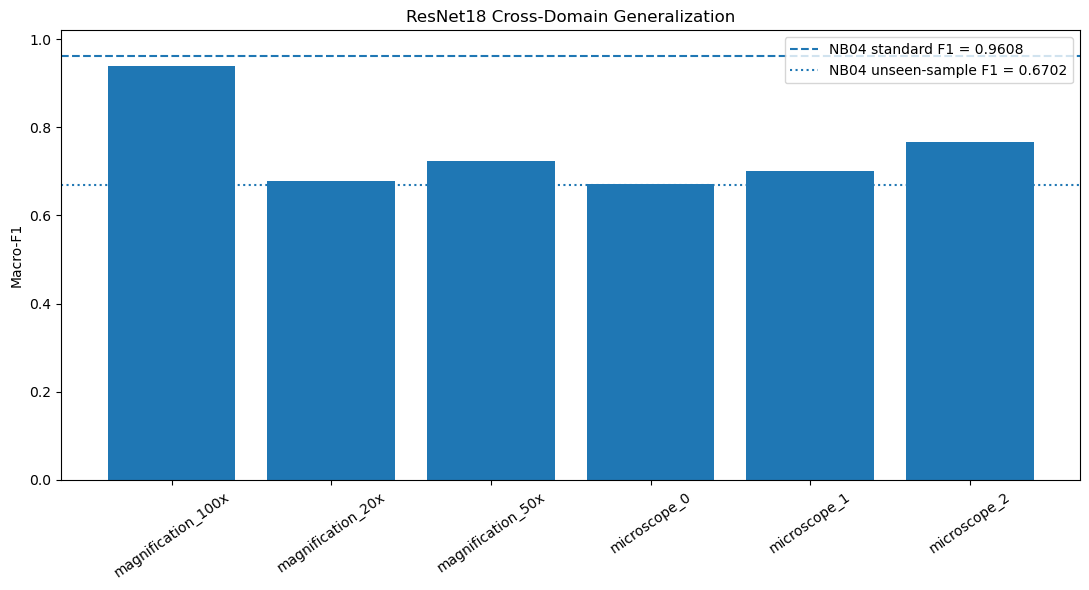

In [11]:
fig,ax=plt.subplots(figsize=(11,6));s=summary.sort_values(["Domain family","Held-out domain"]);ax.bar(s.Experiment,s["Macro F1"]);ax.axhline(.9608,linestyle="--",label="NB04 standard F1 = 0.9608");ax.axhline(.6702,linestyle=":",label="NB04 unseen-sample F1 = 0.6702");ax.set_ylim(0,1.02);ax.set_ylabel("Macro-F1");ax.set_title("ResNet18 Cross-Domain Generalization");ax.tick_params(axis="x",rotation=35);ax.legend();fig.tight_layout();plt.show()


## 7. Confusion matrices and per-class metrics


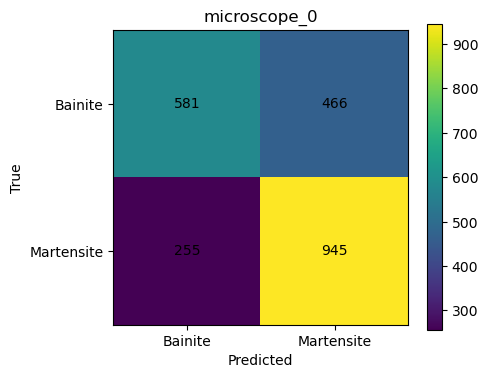

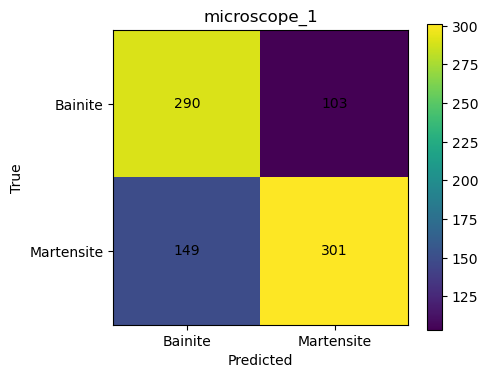

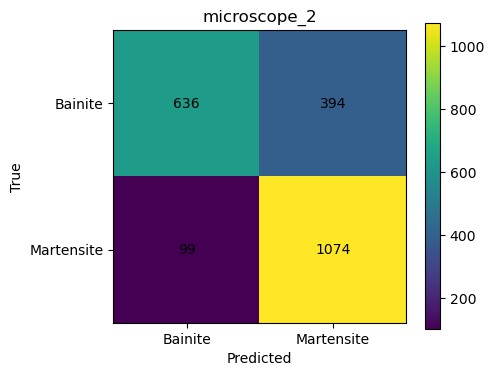

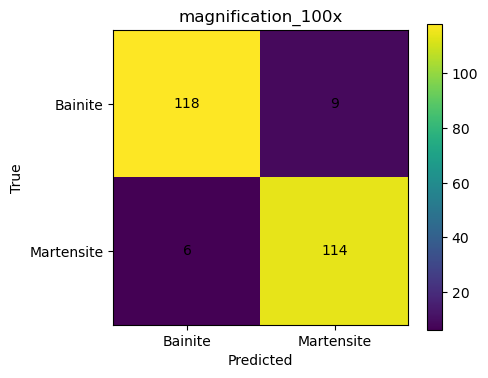

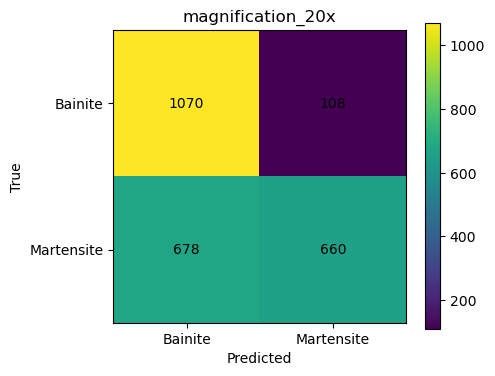

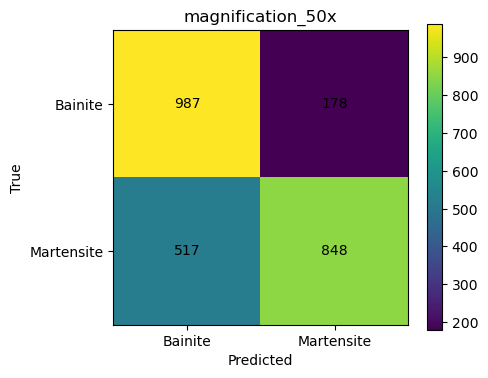

,Experiment,Phase,Precision,Recall,F1,Support
0,microscope_0,Bainite,0.6950,0.5549,0.6171,1047
1,microscope_0,Martensite,0.6697,0.7875,0.7239,1200
2,microscope_1,Bainite,0.6606,0.7379,0.6971,393
3,microscope_1,Martensite,0.7450,0.6689,0.7049,450
4,microscope_2,Bainite,0.8653,0.6175,0.7207,1030
5,microscope_2,Martensite,0.7316,0.9156,0.8133,1173
6,magnification_100x,Bainite,0.9516,0.9291,0.9402,127
7,magnification_100x,Martensite,0.9268,0.9500,0.9383,120
8,magnification_20x,Bainite,0.6121,0.9083,0.7314,1178
9,magnification_20x,Martensite,0.8594,0.4933,0.6268,1338


In [12]:
classes=["Bainite","Martensite"];class_rows=[]
for key,r in results.items():
    cm=confusion_matrix(r["y"],r["p"]);fig,ax=plt.subplots(figsize=(5,4));im=ax.imshow(cm);ax.set_xticks([0,1],classes);ax.set_yticks([0,1],classes);ax.set_xlabel("Predicted");ax.set_ylabel("True");ax.set_title(key)
    for i in range(2):
        for j in range(2):ax.text(j,i,str(cm[i,j]),ha="center",va="center")
    fig.colorbar(im,ax=ax);fig.tight_layout();plt.show()
    rep=classification_report(r["y"],r["p"],target_names=classes,output_dict=True,zero_division=0)
    for c in classes:class_rows.append({"Experiment":key,"Phase":c,"Precision":rep[c]["precision"],"Recall":rep[c]["recall"],"F1":rep[c]["f1-score"],"Support":int(rep[c]["support"])})
class_results=pd.DataFrame(class_rows);display(class_results.style.format({"Precision":"{:.4f}","Recall":"{:.4f}","F1":"{:.4f}"}));class_results.to_csv(RESULT_DIR/"cross_domain_per_class_metrics.csv",index=False)


## 8. ROC curves


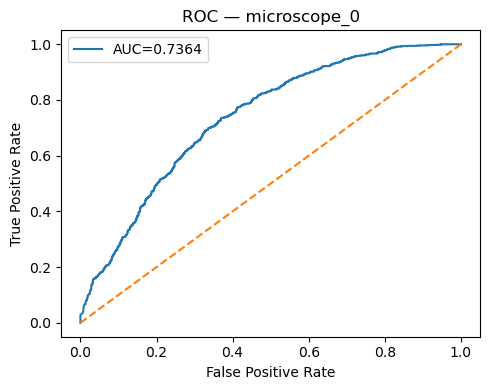

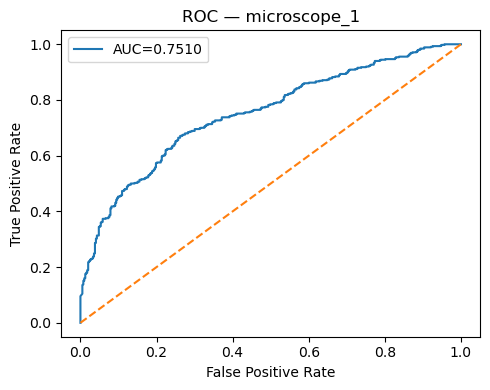

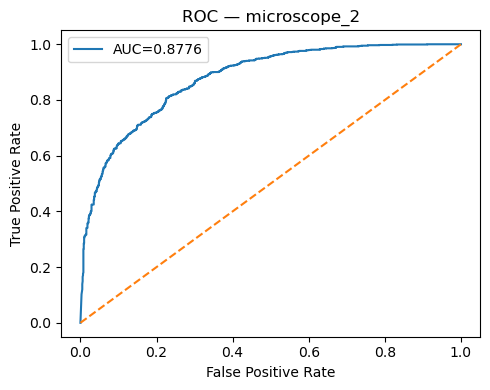

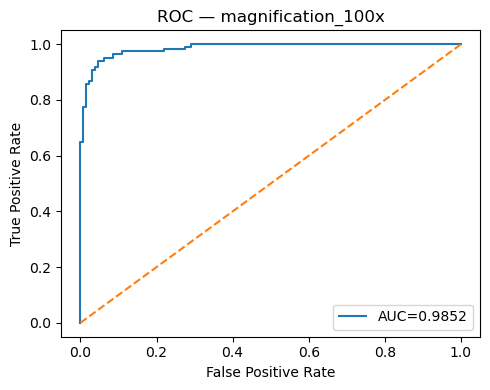

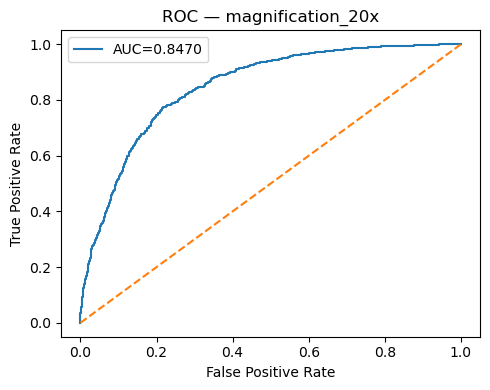

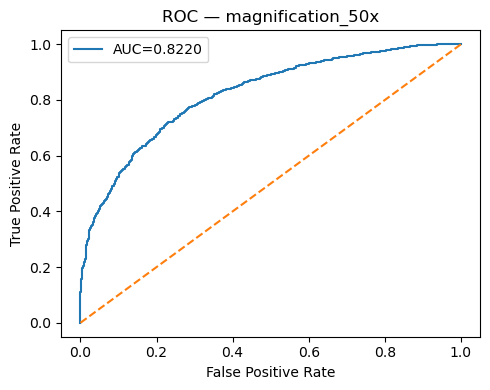

In [13]:
for key,r in results.items():
    fpr,tpr,_=roc_curve(r["y"],r["prob"]);auc=roc_auc_score(r["y"],r["prob"]);fig,ax=plt.subplots(figsize=(5,4));ax.plot(fpr,tpr,label=f"AUC={auc:.4f}");ax.plot([0,1],[0,1],linestyle="--");ax.set_xlabel("False Positive Rate");ax.set_ylabel("True Positive Rate");ax.set_title("ROC — "+key);ax.legend();fig.tight_layout();plt.show()


# 9. Final summary

The 100x holdout has only 247 test images, so interpret it with greater uncertainty than the ~2,500-image 20x/50x tests. A weak holdout identifies sensitivity to that acquisition shift under this protocol; it does not by itself identify the physical cause.


In [14]:
print("="*90);print("CROSS-DOMAIN GENERALIZATION SUMMARY");print("="*90)
for _,r in summary.sort_values(["Domain family","Held-out domain"]).iterrows():
    print(f"\n{r['Domain family']} holdout: {r['Held-out domain']}")
    print(f"  Test images       : {int(r['Test images'])}")
    print(f"  Accuracy          : {r['Accuracy']:.4f}")
    print(f"  Balanced Accuracy : {r['Balanced Accuracy']:.4f}")
    print(f"  Macro-F1          : {r['Macro F1']:.4f}")
    print(f"  ROC-AUC           : {r['ROC-AUC']:.4f}")
    print(f"  Training time     : {r['Training time (min)']:.1f} min")
weak=summary.loc[summary["Macro F1"].idxmin()];strong=summary.loc[summary["Macro F1"].idxmax()]
print("\nNOTEBOOK 04 REFERENCES")
print("  Standard ResNet18 F1      : 0.9608")
print("  Unseen-sample ResNet18 F1 : 0.6702")
print(f"\nHighest domain-holdout F1: {strong['Experiment']} = {strong['Macro F1']:.4f}")
print(f"Lowest domain-holdout F1 : {weak['Experiment']} = {weak['Macro F1']:.4f}")
print("\nNEXT: Notebook 06 — Grad-CAM / representation inspection")
print("="*90)


CROSS-DOMAIN GENERALIZATION SUMMARY

Magnification holdout: 100x
  Test images       : 247
  Accuracy          : 0.9393
  Balanced Accuracy : 0.9396
  Macro-F1          : 0.9393
  ROC-AUC           : 0.9852
  Training time     : 40.3 min

Magnification holdout: 20x
  Test images       : 2516
  Accuracy          : 0.6876
  Balanced Accuracy : 0.7008
  Macro-F1          : 0.6791
  ROC-AUC           : 0.8470
  Training time     : 17.5 min

Magnification holdout: 50x
  Test images       : 2530
  Accuracy          : 0.7253
  Balanced Accuracy : 0.7342
  Macro-F1          : 0.7245
  ROC-AUC           : 0.8220
  Training time     : 28.9 min

Microscope holdout: 0
  Test images       : 2247
  Accuracy          : 0.6791
  Balanced Accuracy : 0.6712
  Macro-F1          : 0.6705
  ROC-AUC           : 0.7364
  Training time     : 27.8 min

Microscope holdout: 1
  Test images       : 843
  Accuracy          : 0.7011
  Balanced Accuracy : 0.7034
  Macro-F1          : 0.7010
  ROC-AUC           : 0.7

# What to send back

After all six runs finish, send the final **CROSS-DOMAIN GENERALIZATION SUMMARY**. That will tell us whether microscope shift, magnification shift, or particular individual acquisition domains are the dominant robustness challenge before we design Grad-CAM and domain-robust training.
